In [20]:
import zipfile

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
fn_zip_package = "../test.zip"
fn_locations = "installation_locations.csv"

In [ ]:
with zipfile.ZipFile(fn_zip_package, "r") as z:
    # 3. Open the specific file inside the zip
    with z.open(fn_locations) as f:
        # 4. Read it into pandas
        df = pd.read_csv(f)

df.head()

,installation_id,latitude,longitude,source,created_at
0,AT_198,48.050715,14.447352,googlemaps,2026-04-19T15:42:12
1,AT_234,48.023512,16.754072,googlemaps,2026-04-19T15:42:12
2,AT_192,46.758285,14.376445,googlemaps,2026-04-19T15:42:12
3,AT_5,48.073079,16.312161,googlemaps,2026-04-19T15:42:12
4,AT_191,47.792897,16.292671,googlemaps,2026-04-19T15:42:12


In [5]:
def haversine_vectorized(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    Args:
        lat1 (float): Latitude of the first point in decimal degrees.
        lon1 (float): Longitude of the first point in decimal degrees.
        lat2 (float): Latitude of the second point in decimal degrees.
        lon2 (float): Longitude of the second point in decimal degrees.

    Returns:
        float: Distance between the two points in kilometers.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of earth in kilometers is 6371 (Use 3956 for miles)
    km = 6371 * c
    return km

In [7]:
# self-merge the dataframe
df_merged = df.merge(df, on="installation_id", suffixes=("_1", "_2"))

df_pairs = df_merged[df_merged["source_1"] < df_merged["source_2"]].copy()

df_pairs["distance_km"] = haversine_vectorized(
    df_pairs["latitude_1"],
    df_pairs["longitude_1"],
    df_pairs["latitude_2"],
    df_pairs["longitude_2"],
)

df_res = df_pairs[
    ["installation_id", "source_1", "source_2", "distance_km"]
].sort_values(by="distance_km")

Text(0, 0.5, '[% of pairs]')

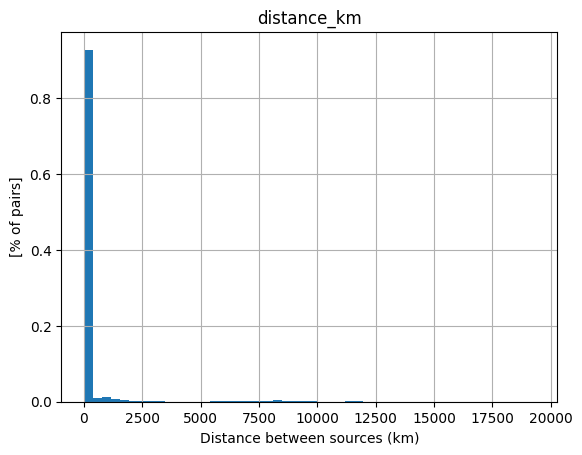

In [21]:
weights = np.ones_like(df_res["distance_km"]) / len(df_res)
ax = plt.gca()
df_res.hist(column="distance_km", bins=50, weights=weights, ax=ax)
ax.set_xlabel("Distance between sources (km)")
ax.set_ylabel("[% of pairs]")